### 9.RNN-Code
Google Stock Price Prediction

In [1]:
import numpy as np 
import pandas as pd

In [2]:
dataset_train = pd.read_csv('Google_Stock_Price_Train.csv')
dataset_train.head()

,Date,Open,High,Low,Close,Volume
0,01-03-2012,325.25,332.83,324.97,663.59,"73,80,500"
1,01-04-2012,331.27,333.87,329.08,666.45,"57,49,400"
2,01-05-2012,329.83,330.75,326.89,657.21,"65,90,300"
3,01-06-2012,328.34,328.77,323.68,648.24,"54,05,900"
4,01-09-2012,322.04,322.29,309.46,620.76,"1,16,88,800"


In [3]:
# No train-test split is needed as we are going to predict the stock price 
# of the next day based on the previous 60 days.
#  So we will use all the data for training.
training_set = dataset_train.iloc[:, 1:2].values
training_set

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]], shape=(1258, 1))

In [7]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
training_set_scaled = mm.fit_transform(training_set)
training_set_scaled
## (X - Xmin) / (Xmax - Xmin)
## It scales the data to a range of [0, 1].
## Converting original value to scaled value --> scaling
## Converting scaled value to original value --> inverse scaling

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]], shape=(1258, 1))

##### Creating a data structure with 60 timesteps and 1 output

In [8]:
X_train = []
y_train = []

for i in range(20, 1258):
    X_train.append(training_set_scaled[i-20:i, 0])
    y_train.append(training_set_scaled[i, 0])

# Here we are using the previous 20 days to predict the stock price of the next day.
# So we are creating a dataset of 20 time steps and 1 output.

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Above we are reshaping the X_train to be in the format of 
# (number of samples, time steps, number of features) 
# which is required for LSTM.

#### Part 2 - Building and Training the RNN

In [9]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

In [10]:
regressor = Sequential()

**Adding the first LSTM Layer**

In [12]:
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Above we have added the first LSTM layer with 50 units and return_sequences=True 
# because we are going to add more LSTM layers after this.
# We have also added a Dropout layer with a dropout rate of 0.2 to prevent overfitting.

**Adding the second LSTM Layer**

In [13]:
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

**Adding the third LSTM Layer**

In [14]:
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

Add layer only when accuracy is increasing

**Adding the Ouput Layer**

In [15]:
regressor.add(Dense(units=1))

**Compiling the RNN**

In [16]:
regressor.compile(optimizer='adam', loss='mean_squared_error')

**Fitting the RNN to the training set**

In [17]:
regressor.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1443
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0960
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0897
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0864
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0848
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0841
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0829
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0828
Epoch 9/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0824
Epoch 10/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0809
Epoch 11/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0806
Epoch 12/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0804
Epoch 13/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0803
Epoch 14/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0800
Epoch 15/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - lo

#### Part 3 - Making the prediction and visualising the results

In [20]:
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')

real_stock_price = dataset_test.iloc[:, 1:2].values

dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)

inputs = dataset_total[len(dataset_total) - len(dataset_test) - 20:].values

inputs = inputs.reshape(-1, 1)

inputs = mm.transform(inputs)

X_test = []
for i in range(60, 80):
    X_test.append(inputs[i-20:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
# Rebuild X_test with the correct 20-timestep windows
X_test = []
for i in range(20, len(inputs)):
    X_test.append(inputs[i - 20:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = regressor.predict(X_test)

# If the model returns a sequence, keep only the last timestep
if predicted_stock_price.ndim == 3:
    predicted_stock_price = predicted_stock_price[:, -1, :]
predicted_stock_price = mm.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step


In [21]:
predicted_stock_price

array([[543.6764 ],
       [543.6378 ],
       [543.633  ],
       [543.63715],
       [543.6726 ],
       [543.74713],
       [543.827  ],
       [543.88354],
       [543.9245 ],
       [543.9517 ],
       [543.9668 ],
       [543.9696 ],
       [543.9656 ],
       [543.9644 ],
       [543.96643],
       [544.015  ],
       [544.0954 ],
       [544.197  ],
       [544.2771 ],
       [544.2733 ]], dtype=float32)

#### Visualising the result

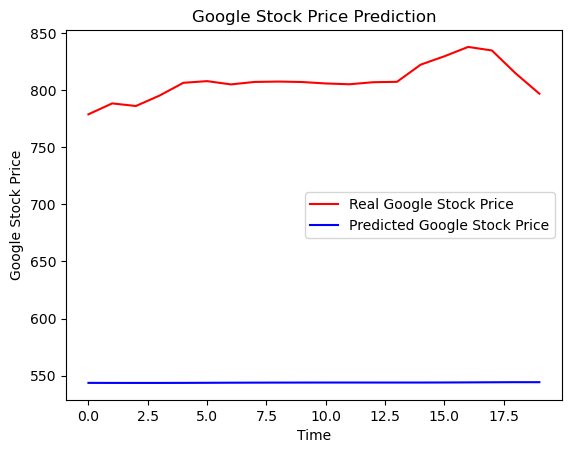

In [22]:
import matplotlib.pyplot as plt
plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()